# Predicción de Propinas en Viajes de Taxi/Uber — EX1(b)

## 1. Contexto y objetivo

El objetivo de este ejercicio (**EX1b**) es predecir la **cantidad de propina** (`target_tip_amount`, en dólares) que dejará un pasajero al final de un viaje de taxi o rideshare en Nueva York, usando únicamente información disponible **antes de que el viaje termine** (features *a priori*).

Esto lo convierte en un problema de **regresión supervisada** a nivel de viaje individual, entrenado sobre datos del dataset TLC (*NYC Taxi & Limousine Commission*).

Las tres preguntas que el modelo responde de forma conjunta son:

| Target | Tipo | Descripción |
|---|---|---|
| `target_tip_amount` | Regresión | Propina en dólares |
| `target_tip_pct` | Regresión | Propina como % del fare |
| `has_tip` | Clasificación binaria | ¿Dejó propina? (0/1) |

En este notebook nos centramos en **`target_tip_amount`**.

## 2. Arquitectura del pipeline

El pipeline sigue una arquitectura de capas:

```
TLC raw data (parquet)
        │
        ▼
  Capa 2 — Estandarización
  (data/standarized/)
        │
        ▼
  Capa 3 — Agregación / Feature engineering   ← ex1b_tips.py
  (data/aggregated/ex1b/df_trip_level_tips/)
        │
        ▼
  Split temporal (train / val / test)          ← split_dataset.py
        │
        ▼
  Entrenamiento Spark ML                       ← model_b_propinas.py
        │
        ▼
  Outputs por año                              ← train_propinas_by_year.py
  (outputs/ml/propinas/by_year/{año}/)
```

Los datos de entrada son **particionados por `year/month`**, lo que permite a Spark aplicar *partition pruning* y procesar solo los datos relevantes para cada año sin leer el dataset completo.

## 3. Capa 2 → Capa 3: Procesamiento del dataset

### 3.1 Fuente de datos

La capa 2 contiene los datos estandarizados del TLC en formato Parquet, particionados por año y mes:

```
data/standarized/
└── year=2023/
│   └── month=10/  ...  month=12/
└── year=2024/
    └── month=10/  ...  month=12/
```

Cada partición contiene columnas de viaje como `pickup_datetime`, `fare_amount`, `tip_amount`, `pu_location_id`, etc. Dado que Yellow Cab y FHV (Uber/Lyft) usan esquemas ligeramente distintos, el pipeline normaliza las diferencias antes de construir el dataset de entrenamiento.

### 3.2 Columnas de entrada seleccionadas

No se cargan todas las columnas del Parquet, sino únicamente las relevantes para el análisis de propinas (`TIP_COLS`). Esto reduce drásticamente el uso de memoria:

```python
TIP_COLS = [
    "service_type", "pickup_datetime", "dropoff_datetime", "date",
    "year", "month", "hour", "day_of_week", "is_weekend", "week_of_year",
    "pu_location_id", "do_location_id",
    "trip_distance", "trip_duration_min",
    "fare_amount", "tip_amount", "tip_pct",
    "passenger_count", "payment_type", "RatecodeID",
    "is_valid_for_tip", "is_valid_for_distance", "is_valid_for_duration", "is_valid_for_price",
    ...
]
```

El procesamiento es **incremental**: se lee y procesa cada fichero Parquet de forma independiente, evitando cargar todo el dataset en memoria a la vez.

## 4. Construcción del dataset a nivel viaje

> Código: `ex1b_tips.py` → función `build_tip_trip_level()`

Esta función transforma los datos crudos de la capa 2 en un dataset limpio y listo para entrenar. Los pasos son:

1. Normalización de tipos
    - Conversión de fechas (pickup_datetime, date) a formato datetime.
    - Conversión de columnas numéricas (fare, tip, distancia, etc.) a tipo numérico.

2. Filtros de calidad
    - Eliminación de filas con datos esenciales faltantes.
    - Se mantienen solo viajes válidos para análisis de propinas.
    - Se eliminan viajes con fare_amount ≤ 0.

3. Creación de variables objetivo (targets)
    - **target_tip_amount**: propina en dólares.
    - **target_tip_pct**: propina en porcentaje.
    - **has_tip**: indicador binario (si hubo propina o no).

4. Selección de columnas finales
    - Se combinan variables temporales, geográficas, de viaje y de pago.
    - El resultado es un dataset estructurado listo para entrenamiento.

El dataset se escribe en formato Parquet particionado por `year/month` en `data/aggregated/ex1b/df_trip_level_tips/`.

## 5. Split temporal

> Código: `split_dataset.py` → función `split_model_propinas()`

Para series temporales, el split aleatorio (shuffle) introduce **data leakage temporal**: el modelo vería datos del futuro durante el entrenamiento. Se usa en cambio un **split por bloques de timestamps únicos**, que garantiza el orden cronológico estricto.

```
Timeline ──────────────────────────────────────────────────────────►
│◄────── 70% train ───────►│◄──── 15% val ────►│◄─── 15% test ────►│
```

### Implementación clave

```python
unique_ts = out["timestamp_hour"].drop_duplicates().sort_values()
n_steps   = len(unique_ts)

n_train = int(n_steps * train_frac)   # 70%
n_val   = int(n_steps * val_frac)     # 15%
# test  = el resto                    # 15%

train_end_ts  = unique_ts.iloc[n_train - 1]
val_start_ts  = unique_ts.iloc[n_train]
val_end_ts    = unique_ts.iloc[n_train + n_val - 1]
test_start_ts = unique_ts.iloc[n_train + n_val]
```

**Por qué `timestamp_hour` y no filas:** al cortar por timestamps únicos, todos los viajes de la misma hora quedan en el mismo bloque. Esto evita que muestras del mismo instante temporal aparezcan en train y test simultáneamente.

## 6. Uso de Spark

1. Configuración
    - Ajuste de particiones (shuffle.partitions = 16) para mejorar rendimiento.
    - Desactivación de Arrow para compatibilidad.

2. Preparación del DataFrame
    - Conversión de tipos (fechas, enteros).
    - Filtrado por `year/month` antes de leer completamente los datos.
    - Creación de `timestamp_hour` directamente en Spark.
    - Eliminación de valores nulos o inválidos en el target.

3. Pipeline de preprocesamiento Spark ML

Para entrenar modelos con la API de Spark MLlib, las features deben estar en un único vector denso. El pipeline hace:

```python
# 1. StringIndexer para variables categóricas (si las hay)
StringIndexer(inputCol="payment_type", outputCol="payment_type__idx", handleInvalid="keep")

# 2. VectorAssembler: junta todas las features numéricas + indexadas
VectorAssembler(
    inputCols=[*num_cols, *indexed_cat_cols],
    outputCol="features",
    handleInvalid="skip"   # descarta filas con nulos en features
)
```

El `Pipeline` de Spark encadena estos pasos y se ajusta (`fit`) sobre train, luego se aplica (`transform`) sobre val y test, garantizando que no hay fuga de estadísticas de val/test hacia train.

## 7. Selección de features y prevención de data leakage

Este es uno de los aspectos más críticos del diseño. Se definen dos modos:

### `strict_apriori` (modo por defecto)

Elimina todas las columnas que **no estarían disponibles antes de que el viaje termine**:

```python
STRICT_APRIORI_DROP_COLS = [
    "pickup_datetime",     # redundante con hour/day_of_week
    "dropoff_datetime",    # no disponible a priori
    "trip_duration_min",   # no disponible a priori (el viaje no ha terminado)
    "fare_amount",         # calculado al final del viaje
    "total_amount_std",    # calculado al final del viaje
    "tip_amount",          # ES el target, no puede ser feature
    "tip_pct",             # derivado del target
    "has_tip",             # derivado del target
    "target_tip_amount",   # target
    "target_tip_pct",      # target alternativo
]
```

### `all`

Mantiene columnas como `fare_amount` y `trip_duration_min`. Útil para análisis post-hoc o como cota superior de rendimiento, pero **no debe usarse en producción**.

### Features disponibles en modo `strict_apriori`

| Feature | Descripción |
|---|---|
| `hour` | Hora del día (0–23) |
| `day_of_week` | Día de la semana (0=lunes) |
| `is_weekend` | Booleano fin de semana |
| `week_of_year` | Semana del año |
| `month` | Mes |
| `year` | Año |
| `pu_location_id` | ID zona de recogida |
| `do_location_id` | ID zona de destino |
| `trip_distance` | Distancia del viaje (millas) |
| `passenger_count` | Número de pasajeros |
| `payment_type` | Método de pago (tarjeta, efectivo...) |
| `RatecodeID` | Tipo de tarifa (estándar, aeropuerto...) |
| `service_type` | Yellow cab, FHV, etc. |

## 8. Modelos entrenados

Se entrenaron cuatro modelos, de complejidad creciente:

### 8.1 `dummy_median`

**Baseline estadístico.** Predice la mediana de `target_tip_amount` calculada sobre el conjunto de train. No aprende ningún patrón.

```python
median_value = float(train_df.approxQuantile(target_col, [0.5], 0.01)[0])
# Para cualquier viaje: prediction = median_value
sdf = sdf.withColumn("prediction", F.lit(median_value).cast("double"))
```

Su función es establecer el **mínimo rendimiento esperado**: cualquier modelo real debe superar este baseline.

### 8.2 `elastic_net`

**Regresión lineal regularizada** (combinación de L1 y L2). Asume relaciones lineales entre features y target.

```python
LinearRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=100,
    regParam=0.1,          # fuerza de regularización
    elasticNetParam=0.25   # 25% L1 (Lasso) + 75% L2 (Ridge)
)
```

La regularización evita el sobreajuste y realiza selección implícita de features (L1 lleva algunos coeficientes a cero).

### 8.3 `random_forest`

**Ensemble de árboles de decisión** con bagging. Cada árbol se entrena sobre una muestra aleatoria de los datos y una submuestra de features.

```python
RandomForestRegressor(
    labelCol="label",
    featuresCol="features",
    numTrees=80,    # número de árboles
    maxDepth=10     # profundidad máxima por árbol
)
```

Captura relaciones no lineales y es robusto al sobreajuste gracias al promediado entre árboles.

### 8.4 `hist_gradient_boosting` (GBT)

**Gradient Boosted Trees**. Construye árboles secuencialmente, donde cada árbol corrige los errores del anterior.

```python
GBTRegressor(
    labelCol="label",
    featuresCol="features",
    maxIter=80,   # número de árboles (iteraciones de boosting)
    maxDepth=8    # profundidad máxima
)
```

Suele ser el modelo con mayor rendimiento en datos tabulares estructurados, al precio de mayor tiempo de entrenamiento.

## 9. Entrenamiento por año

> Código: `train_propinas_by_year.py`

En lugar de entrenar un único modelo sobre todos los años, se entrena un **modelo independiente por año** (usando solo el Q4 de cada año: octubre–diciembre). Esto tiene dos ventajas:

1. **Detección de drift temporal:** si las métricas empeoran año a año, indica que el comportamiento de las propinas está cambiando.
2. **Modelos más específicos:** un modelo entrenado en datos de 2024 puede capturar condiciones económicas y tarifas de ese año concreto.

### Rango de fechas por año

```python
def get_year_date_range(year: int) -> tuple[str, str]:
    return f"{year}-10-01", f"{year}-12-31"
```

### Estructura de outputs

```
outputs/ml/propinas/
└── by_year/
    ├── 2023/
    │   ├── dataset_profile.json          # estadísticas del dataset
    │   ├── training_summary.json         # resumen del entrenamiento
    |   └── {model}/
    │       ├── {model}_report.json           # métricas por modelo
    │       ├── {model}_spark_model/          # modelo serializado (Spark ML)
    │       └── {model}_test_predictions.parquet
    ├── 2024/  (idem)
    ├── 2025/  (idem)
    └── consolidation_report.json         # leaderboard consolidado
```

## Análisis global de métricas

- **Superación del Baseline (`dummy_median`)**

El modelo base (`dummy_median`) tiene un rendimiento muy pobre, con un R2 ligeramente negativo (entre **-0.002** y **-0.014**) y un error absoluto medio (MAE) de aproximadamente **$2.50**. Esto confirma que predecir la propina usando solo la mediana histórica no es útil, y valida la necesidad de modelos de Machine Learning. Todos los demás modelos superan con creces este baseline.

- **Essembles basados en árboles**

Los modelos de árboles dominan: `hist_gradient_boosting` (HGB) es el ganador indiscutible, seguido muy de cerca por el `random_forest`. Ambos superan ampliamente al modelo lineal (`elastic_net`), demostrando que la relación entre las variables de viaje y la propina es compleja y no lineal. En 2023, HGB logró el mejor desempeño general con un R2 de **~0.67**.

- **Existe degradación temporal (Concept Drift)**

El rendimiento de todos los modelos empeora progresivamente entre 2023 y 2025 (por ejemplo, el R2 de HGB cae de 0.668 a 0.630). Esto confirma que el comportamiento de las propinas cambia con el tiempo y valida nuestra decisión de entrenar modelos independientes por año.

Leaderboard Global (Métricas de Test):


,Year,Model,MAE,RMSE,R2
0,2023,hist_gradient_boosting,1.078725,2.188524,0.668393
1,2023,random_forest,1.096713,2.195156,0.666381
2,2023,elastic_net,1.550074,2.682696,0.501731
3,2023,dummy_median,2.540722,4.036681,-0.009354
4,2024,hist_gradient_boosting,1.137789,2.205002,0.649704
5,2024,random_forest,1.151868,2.213844,0.646889
6,2024,elastic_net,1.576817,2.675422,0.484295
7,2024,dummy_median,2.499644,3.949154,-0.014602
8,2025,hist_gradient_boosting,1.211914,2.371508,0.630920
9,2025,random_forest,1.226172,2.378016,0.628891


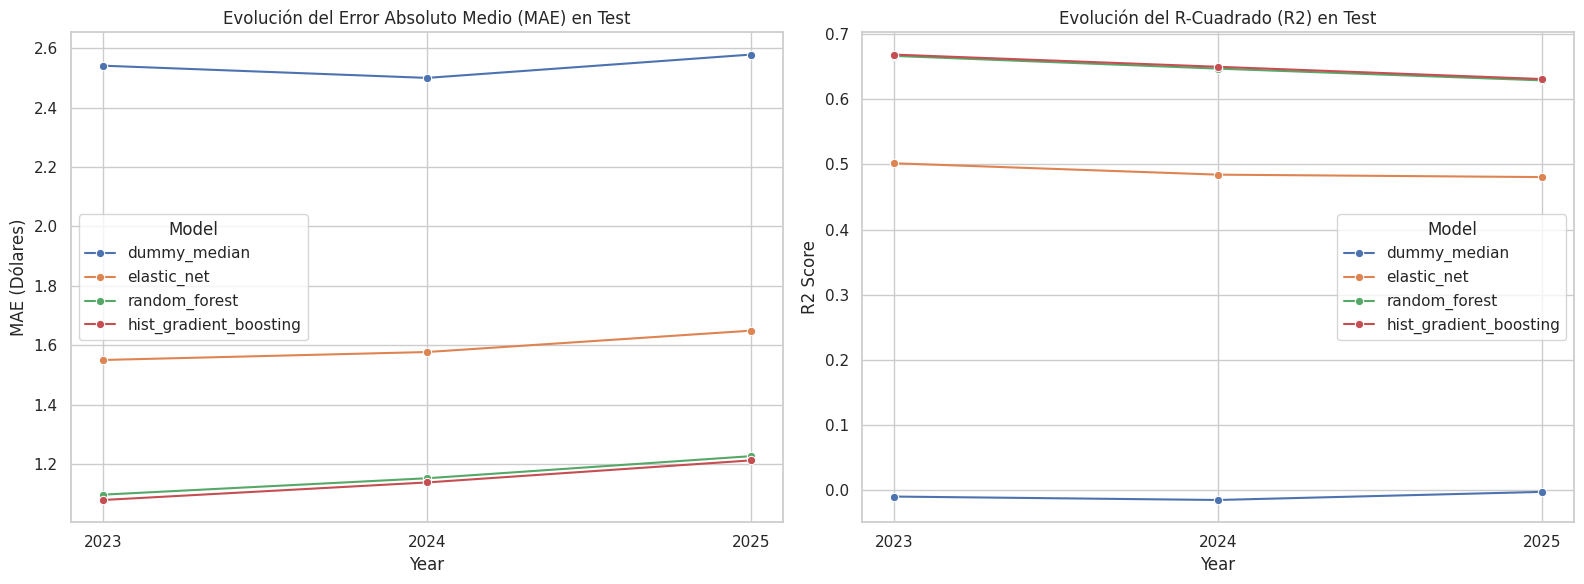

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

report_path = "../outputs/ml/propinas/by_year/consolidation_report.json"

with open(report_path, 'r') as f:
    leaderboard_data = json.load(f)

# Extraer métricas de TEST
records = []
for year, year_data in leaderboard_data['results'].items():
    for model_name, model_data in year_data['models'].items():
        metrics_test = model_data['metrics']['test']
        records.append({
            'Year': int(year),
            'Model': model_name,
            'MAE': metrics_test['mae'],
            'RMSE': metrics_test['rmse'],
            'R2': metrics_test['r2']
        })

df_metrics = pd.DataFrame(records)

# Mostrar el Leaderboard ordenado
print("Leaderboard Global (Métricas de Test):")
display(df_metrics.sort_values(by=['Year', 'RMSE']).reset_index(drop=True))

# Evolución del MAE y R2 por modelo a lo largo de los años
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: MAE (Menor es mejor)
sns.lineplot(data=df_metrics, x='Year', y='MAE', hue='Model', marker='o', ax=axes[0])
axes[0].set_title('Evolución del Error Absoluto Medio (MAE) en Test')
axes[0].set_xticks(df_metrics['Year'].unique())
axes[0].set_ylabel('MAE (Dólares)')

# Gráfico 2: R2 (Mayor es mejor)
sns.lineplot(data=df_metrics, x='Year', y='R2', hue='Model', marker='o', ax=axes[1])
axes[1].set_title('Evolución del R-Cuadrado (R2) en Test')
axes[1].set_xticks(df_metrics['Year'].unique())
axes[1].set_ylabel('R2 Score')

plt.tight_layout()
plt.show()

## Interpretabilidad del modelo: Feature Importance

- **La distancia es el factor dominante:** La variable `trip_distance` domina por completo las decisiones del modelo, con un **~48.8%** de importancia en 2025. Esto tiene todo el sentido lógico: a mayor distancia, mayor es el costo total (`fare_amount`), y los pasajeros suelen calcular la propina como un porcentaje de ese costo.

- **El método de pago es crítico:** `payment_type` es la segunda variable más relevante (**26.34%**). En el ecosistema de taxis de Nueva York, las propinas pagadas en efectivo rara vez se registran en los sistemas (aparecen como 0), mientras que las pagadas con tarjeta siempre quedan trazadas. El modelo ha aprendido a identificar este patrón administrativo

- **El contexto geográfico y temporal es secundario:** Las variables de ubicación (`do_location_id` con 5.2% y `pu_location_id` con 4.39%) y de tiempo (`hour` con 5.45%) tienen una influencia moderada pero mucho menor que la distancia y el pago. Variables como el mes, el día de la semana o si es fin de semana (is_weekend) son prácticamente irrelevantes para predecir el monto exacto.

- **Validación de la arquitectura:** Al trabajar bajo el esquema `strict_apriori`, el modelo no tiene acceso directo al costo total del viaje (`fare_amount`). Que haya logrado apoyarse en la distancia para inferir la tarifa implícita y predecir la propina valida nuestro diseño y asegura que no hay data leakage (fuga de información del futuro).

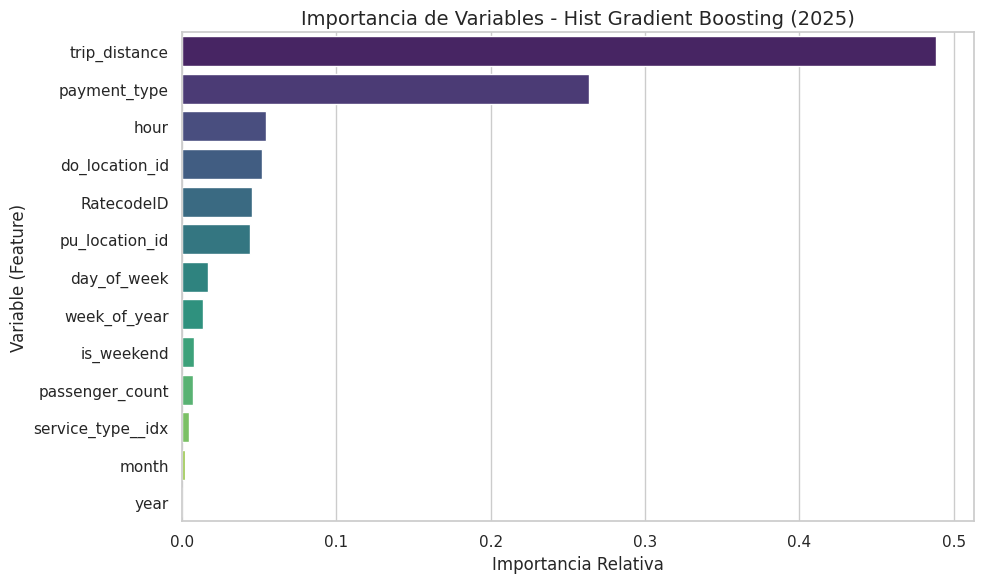

,feature,importance_%
0,trip_distance,48.87%
1,payment_type,26.34%
2,hour,5.45%
3,do_location_id,5.2%
4,RatecodeID,4.52%
5,pu_location_id,4.39%
6,day_of_week,1.71%
7,week_of_year,1.37%
8,is_weekend,0.77%
9,passenger_count,0.72%


In [2]:
with open(report_path, 'r') as f:
    leaderboard_data = json.load(f)

# Extraer importancia de variables del mejor modelo (HGB) en el último año (2025)
hgb_2025_features = leaderboard_data['results']['2025']['models']['hist_gradient_boosting']['feature_importance']
df_importance = pd.DataFrame(hgb_2025_features)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance,
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.title('Importancia de Variables - Hist Gradient Boosting (2025)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable (Feature)', fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar la tabla formateada como porcentajes
df_importance['importance_%'] = (df_importance['importance'] * 100).round(2).astype(str) + '%'
display(df_importance[['feature', 'importance_%']])

## Evaluación de predicciones

- **Sesgo casi nulo:** El bias de -0.0850 es excelente. Indica que, en promedio, el modelo solo se equivoca por unos 8 centavos de dólar. Esto significa que el modelo está muy bien calibrado: no tiende a sobreestimar ni a subestimar el monto de la propina de manera sistemática en la masa global de datos.

- **Precisión en el rango "estándar":** La mayor densidad de puntos se concentra entre 2 y 8 dólares, alineándose muy bien con la línea roja. El modelo es muy fiable para predecir propinas en viajes urbanos habituales.

- **Conservadurismo en propinas altas:** Se observa que, a medida que la propina real aumenta (más de $20), los puntos tienden a situarse por debajo de la línea diagonal. Esto sugiere que el modelo es "conservador": le cuesta predecir propinas excepcionalmente altas, probablemente porque estas dependen de factores emocionales o de calidad de servicio que no están presentes en nuestras variables a priori.

- **El fenómeno del “pasajero no tipper”** se manifiesta como una concentración vertical en x=0, correspondiente a trayectos en los que el modelo anticipaba una propina (entre 1 y 5 dólares), pero finalmente no se produjo. Este patrón refleja una limitación inherente del modelo: aunque capta tendencias generales a partir de variables como la distancia o el tipo de pago, no logra incorporar factores subjetivos o circunstanciales —como la experiencia del servicio— que influyen en la decisión real del pasajero.

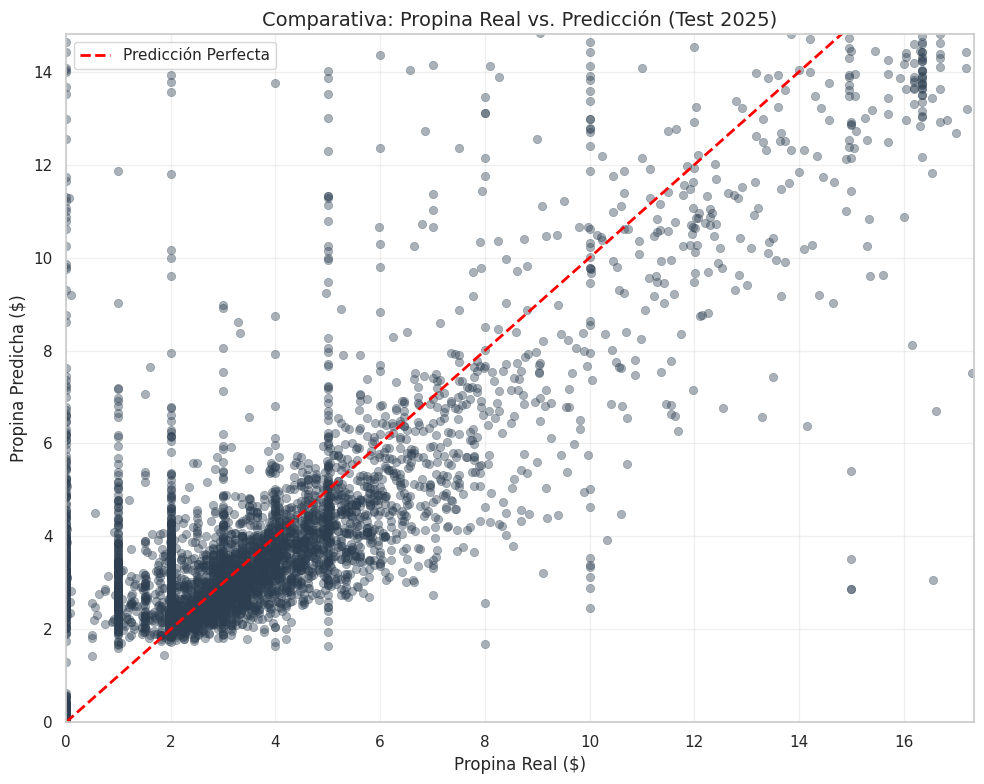

Análisis completado. Sesgo medio (Bias): -0.0850


In [3]:
# Cargar las predicciones
preds_path = "../outputs/ml/propinas/by_year/2025/hist_gradient_boosting/hist_gradient_boosting_test_predictions.parquet"
df_preds = pd.read_parquet(preds_path)

# Muestreo para visualización
# Tomamos 5,000 puntos aleatorios para que el scatter plot sea legible
df_sample = df_preds.sample(n=min(5000, len(df_preds)), random_state=42)

# Crear el gráfico
plt.figure(figsize=(10, 8))

# Scatter plot con transparencia para ver densidad
sns.scatterplot(
    data=df_sample, 
    x='y_true', 
    y='y_pred', 
    alpha=0.4, 
    color='#2c3e50',
    edgecolor=None
)

# Línea de identidad (y = x) - El ideal donde la predicción es perfecta
max_val = max(df_sample['y_true'].max(), df_sample['y_pred'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Predicción Perfecta')

plt.title('Comparativa: Propina Real vs. Predicción (Test 2025)', fontsize=14)
plt.xlabel('Propina Real ($)', fontsize=12)
plt.ylabel('Propina Predicha ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustamos los límites excluyendo el 1% de los outliers más extremos para no deformar el gráfico
plt.xlim(0, df_sample['y_true'].quantile(0.99))
plt.ylim(0, df_sample['y_pred'].quantile(0.99))

plt.tight_layout()
plt.show()

# Cálculo rápido del error residual medio (Bias)
residual_mean = (df_preds['y_true'] - df_preds['y_pred']).mean()
print(f"Análisis completado. Sesgo medio (Bias): {residual_mean:.4f}")